In [5]:
!pip install -q alpaca-py yfinance backtesting pandas matplotlib

import yfinance as yf
from alpaca.trading.client import TradingClient

API_KEY = "PK76JOMPRY3IEBM7JJ2OE6W53M"
SECRET_KEY = "HydLx52pdHJoJQEWR3epVaDrLwmYR2JSmqhw9ib8JB2k"

try:
  trading_client = TradingClient(API_KEY, SECRET_KEY, paper=True)
  account = trading_client.get_account()
  print("ALPACA CONNECTION SUCCESSFUL")
  print(f"Account Status : {account.status}")
  print(f"Buying Power : ${float(account.buying_power):,.2f}")
  print(f"Portfolio Value: ${float(account.portfolio_value):,.2f}\n")

except Exception as e:
  print("ALPACA CONNECTION FAILED")
  print(f"Error details: {e}\n")

df = yf.download("SPY", period= "1y", interval = "1d", progress = False)
print("HISTORICAL DATA SUCCESSFUL")
print("Last 5 rows of SPY daily price data:")
print(df[['Open', 'High', 'Low','Close','Volume']].tail())

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 128.9/128.9 kB 5.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 190.8/190.8 kB 12.0 MB/s eta 0:00:00
ALPACA CONNECTION SUCCESSFUL
Account Status : AccountStatus.ACTIVE
Buying Power : $300,272.11
Portfolio Value: $100,000.00



/tmp/ipykernel_2228/3088161631.py:21: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download("SPY", period= "1y", interval = "1d", progress = False)


HISTORICAL DATA SUCCESSFUL
Last 5 rows of SPY daily price data:
Price             Open        High         Low       Close    Volume
Ticker             SPY         SPY         SPY         SPY       SPY
Date                                                                
2026-09-21  766.250000  774.890015  766.030029  773.500000  50484700
2026-09-22  774.030029  775.140015  772.570007  773.380005  34802300
2026-09-23  772.789978  773.049988  766.500000  767.809998  54931700
2026-09-24  764.070007  768.950012  763.250000  767.179993  43983700
2026-09-25  768.780029  772.280029  766.289978  771.349976  36629600


Step 2: Downloading Multi-Asset Historical Data


/tmp/ipykernel_2228/24816638.py:8: FutureWarning: YF.download() has changed argument auto_adjust default to True
  raw_data = yf.download(tickers, period = "1y", interval = "1d", progress = False)



Latest Prices ($USD):
Ticker            BNO         GLD         SPY
Date                                         
2026-09-21  58.869999  398.380005  773.500000
2026-09-22  57.910000  400.070007  773.380005
2026-09-23  60.360001  392.880005  767.809998
2026-09-24  61.840000  391.690002  767.179993
2026-09-25  59.650002  393.410004  771.349976


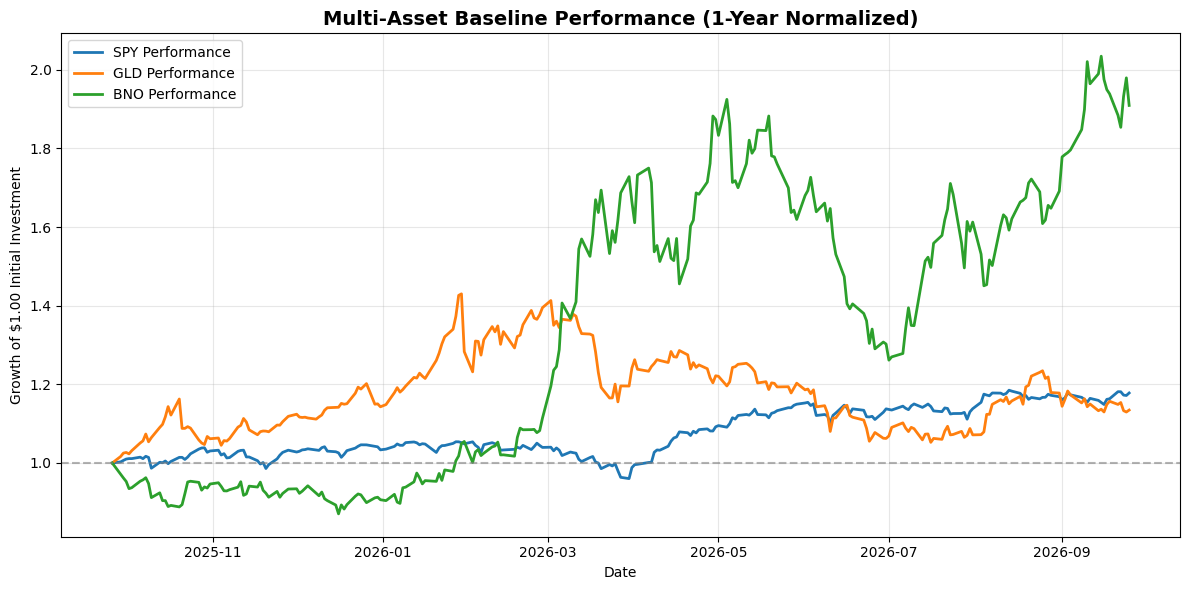


30-Day Annualized Volatility (%)
SPY  Volatility: 9.79%
GLD  Volatility: 24.45%
BNO  Volatility: 41.55%


In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

tickers = ["SPY", "GLD", "BNO"]

print("Step 2: Downloading Multi-Asset Historical Data")
raw_data = yf.download(tickers, period = "1y", interval = "1d", progress = False)

close_prices = raw_data['Close']

close_prices = close_prices.dropna()

print("\nLatest Prices ($USD):")
print(close_prices.tail(5))

normalized_prices = close_prices / close_prices.iloc[0]

plt.figure(figsize=(12,6))
for t in tickers:
  plt.plot(normalized_prices.index, normalized_prices[t], label=f"{t} Performance", linewidth=2)

plt.title("Multi-Asset Baseline Performance (1-Year Normalized)", fontsize=14, fontweight='bold')
plt.xlabel("Date")
plt.ylabel("Growth of $1.00 Initial Investment")
plt.axhline(1.0, color='gray', linestyle = '--', alpha = 0.6)
plt.legend(loc="upper left")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

daily_returns = close_prices.pct_change().dropna()

print("\n30-Day Annualized Volatility (%)")
rolling_vol_30d = daily_returns.tail(30).std()*np.sqrt(252)*100
for t in tickers:
  print(f"{t:4s} Volatility: {rolling_vol_30d[t]:.2f}%")


In [7]:
import numpy as np
import pandas as pd

print("Step 3: Dynamic Risk Parity Weighting & Order Exectution")

account = trading_client.get_account()
portfolio_value = float(account.portfolio_value)
buying_power = float(account.buying_power)

print(f"Total Portfolio Value : ${portfolio_value:,.2f}")
print(f"Available Buying Power : ${buying_power:,.2f}")

vol_30d = rolling_vol_30d / 100

inv_vol = 1.0 / vol_30d
risk_parity_weights = inv_vol / inv_vol.sum()

print("Risk Parity Target Allocations")
for t in tickers:
  print(f"{t:4s} | Volatility : {vol_30d[t]*100:5.2f}% | Target Weight: {risk_parity_weights[t]*100:5.2f}%")

latest_prices = close_prices.iloc[-1]
target_shares = {}

print("\n Target Orders for Portfolio Execution")
for t in tickers:
  target_dollars = portfolio_value * risk_parity_weights[t]
  shares = int(target_dollars // latest_prices[t])
  target_shares[t] = shares
  actual_allocation = (shares * latest_prices[t]) / portfolio_value * 100

  print(f"{t:4s} | Price: ${latest_prices[t]:6.2f} | Target: ${target_dollars:9.2f} | Quantity: {shares:4d} shares ({actual_allocation:.2f}% of portfolio)")

Step 3: Dynamic Risk Parity Weighting & Order Exectution
Total Portfolio Value : $100,000.00
Available Buying Power : $300,272.11
Risk Parity Target Allocations
SPY  | Volatility :  9.79% | Target Weight: 61.12%
GLD  | Volatility : 24.45% | Target Weight: 24.48%
BNO  | Volatility : 41.55% | Target Weight: 14.40%

 Target Orders for Portfolio Execution
SPY  | Price: $771.35 | Target: $ 61118.02 | Quantity:   79 shares (60.94% of portfolio)
GLD  | Price: $393.41 | Target: $ 24477.22 | Quantity:   62 shares (24.39% of portfolio)
BNO  | Price: $ 59.65 | Target: $ 14404.76 | Quantity:  241 shares (14.38% of portfolio)


In [8]:
from alpaca.trading.requests import MarketOrderRequest
from alpaca.trading.enums import OrderSide, TimeInForce

print("Step 4: Transmitting Multi-Asset Orders to Alpaca")

for t, qty in target_shares.items():
  if qty > 0:
    try:
      order_data = MarketOrderRequest(symbol=t,qty=qty,side=OrderSide.BUY,time_in_force=TimeInForce.GTC)
      order = trading_client.submit_order(order_data=order_data)
      print(f"[Success] {t:4s} | Transmitted Buy Order for {qty:4d} shares | Order ID: {order.id}")
    except Exception as e:
      print(f"[Failed] {t:4s} | Execution failed: {e}")
  else:
    print(f"[Skipped] {t:4s} | Share count is 0. No order submitted.")



Step 4: Transmitting Multi-Asset Orders to Alpaca
[Success] SPY  | Transmitted Buy Order for   79 shares | Order ID: f43f9c22-a606-4f06-86f7-3564a47cd1d2
[Success] GLD  | Transmitted Buy Order for   62 shares | Order ID: 473a4805-69f8-4658-aebf-b30f13ed648a
[Success] BNO  | Transmitted Buy Order for  241 shares | Order ID: 36ef824e-8dd7-4dcf-8970-d0d0d67fbd12


Step 5: 1-Year Historical Backtest


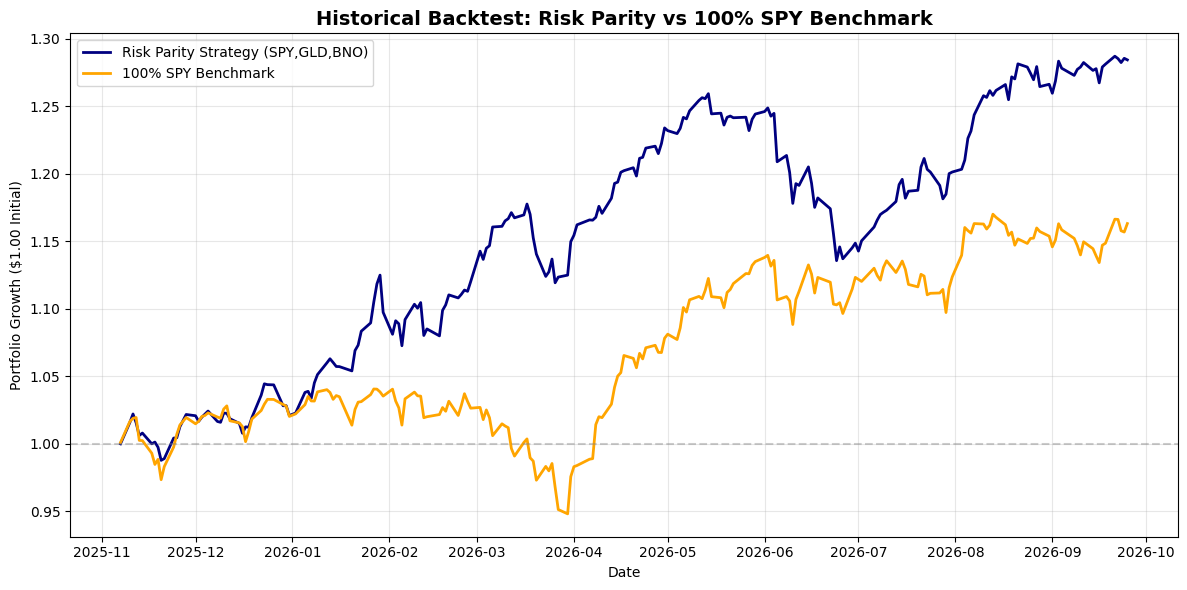

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("Step 5: 1-Year Historical Backtest")

daily_rets = close_prices.pct_change().dropna()

rolling_vol = daily_rets.rolling(window=30).std()*np.sqrt(252)

inv_vol_df = 1.0/rolling_vol
dynamic_weights = inv_vol_df.div(inv_vol_df.sum(axis=1), axis=0).dropna()

aligned_rets = daily_rets.loc[dynamic_weights.index]

strategy_returns = (aligned_rets*dynamic_weights.shift(1)).sum(axis=1).dropna()

benchmark_returns = aligned_rets['SPY'].loc[strategy_returns.index]

strategy_cum = (1+strategy_returns).cumprod()
benchmark_cum = (1+benchmark_returns).cumprod()

plt.figure(figsize=(12,6))
plt.plot(strategy_cum.index, strategy_cum, label="Risk Parity Strategy (SPY,GLD,BNO)", color="navy", linewidth=2)
plt.plot(benchmark_cum.index, benchmark_cum, label="100% SPY Benchmark", color="orange",linewidth=2)

plt.title("Historical Backtest: Risk Parity vs 100% SPY Benchmark", fontsize=14, fontweight="bold")
plt.xlabel("Date")
plt.ylabel("Portfolio Growth ($1.00 Initial)")
plt.legend(loc="upper left")
plt.axhline(1.0, color= 'gray', linestyle = '--', alpha = 0.4)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [47]:
from scipy.stats import norm
import yfinance as yf
import pandas as pd

print("Step 6: Quant Risk Tear Sheet")

TNX = yf.download("^TNX", period = "1y", interval = "1d", progress = False, auto_adjust=False)
rf = float(TNX['Close'].iloc[-1].item()) / 100

# Strategy Metrics
ann_return = strategy_returns.mean()*252
ann_vol = strategy_returns.std()*np.sqrt(252)

sharpe = (ann_return - rf) / ann_vol
downside_vol = strategy_returns[strategy_returns < 0].std()*np.sqrt(252)
sortino = (ann_return - rf) / downside_vol

running_max = strategy_cum.cummax()
drawdown = (strategy_cum - running_max) / running_max
max_drawdown = drawdown.min()

var_95_1d = -(strategy_returns.mean() + strategy_returns.std()*norm.ppf(0.05))

# Benchmark Metrics
ann_ret_bench = benchmark_returns.mean() * 252
ann_vol_bench = benchmark_returns.std() * np.sqrt(252)

sharpe_bench = (ann_ret_bench - rf) / ann_vol_bench
downside_vol_bench = benchmark_returns[benchmark_returns < 0].std() * np.sqrt(252)
sortino_bench = (ann_ret_bench - rf) / downside_vol_bench

running_max_bench = benchmark_cum.cummax()
mdd_bench = ((benchmark_cum - running_max_bench) / running_max_bench).min()
var_95_bench = -(benchmark_returns.mean() + benchmark_returns.std() * norm.ppf(0.05))

tear_sheet_df = pd.DataFrame({
    "Metric": [
        "Annualized Return",
        "Annualized Volatility",
        f"Sharpe Ratio (Rf = {rf*100:.2f}%)",
        "Sortino Ratio (Downside)",
        "Max Drawdown (Peak-to-Trough)",
        "1-Day 95% Value at Risk (VaR)"
    ],
    "Risk Parity Strategy": [
        f"{ann_return*100:8.2f}%",
        f"{ann_vol*100:8.2f}%",
        f"{sharpe:8.2f}",
        f"{sortino:8.2f}",
        f"{max_drawdown*100:8.2f}%",
        f"{var_95_1d*100:8.2f}%"
    ],
    "100% SPY Benchmark": [
        f"{ann_ret_bench*100:8.2f}%",
        f"{ann_vol_bench*100:8.2f}%",
        f"{sharpe_bench:8.2f}",
        f"{sortino_bench:8.2f}",
        f"{mdd_bench*100:8.2f}%",
        f"{var_95_bench*100:8.2f}%"
    ]
})

print()
print(tear_sheet_df.to_string(index=False, col_space=24),end="\n\n")




Step 6: Quant Risk Tear Sheet

                       Metric     Risk Parity Strategy       100% SPY Benchmark
            Annualized Return                   29.36%                   18.08%
        Annualized Volatility                   12.69%                   12.99%
    Sharpe Ratio (Rf = 5.18%)                     1.90                     0.99
     Sortino Ratio (Downside)                     2.55                     1.53
Max Drawdown (Peak-to-Trough)                   -9.82%                   -8.88%
1-Day 95% Value at Risk (VaR)                    1.20%                    1.27%

